# 01 — MCI 24-Month Cohort Audit

**Study pivot.** From *"Can blood biomarkers predict current Alzheimer's severity?"*
to:

> **Among participants with MCI at the time of blood draw, can a small blood-biomarker
> panel help identify who is at higher risk of progression to dementia within 24 months?**

Intended eventual use: a **clinician-facing risk-stratification / triage** aid — *not* a
direct-to-consumer diagnostic.

**This notebook does NOT build or tune any model.** It is a *cohort-definition,
data-quality, outcome-feasibility, and reproducibility audit* that establishes whether
the ADNI-derived data in this project can support the future study.

- **Target population:** participants classified as MCI at an anchor (blood-draw) visit.
- **Prediction target (future):** conversion MCI → dementia within 24 months of anchor.
- **Candidate panel (future):** plasma p-tau217, Aβ42, Aβ40, Aβ42/Aβ40, NfL, GFAP, APOE4 count, age.

All variable names, labels, units and timepoints below are documented from the actual
project files — nothing is invented. Where an expected variable does **not** exist in the
data (e.g. sex, education, comorbidities), that absence is reported explicitly.


## 0. Setup, paths, and configuration

In [1]:
from __future__ import annotations

import os
import sys
import textwrap
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
matplotlib.rcParams["figure.dpi"] = 110


def find_project_root(start: Path) -> Path:
    """Walk upward until we find the folder that contains Data/raw."""
    cur = start.resolve()
    for cand in [cur, *cur.parents]:
        if (cand / "Data" / "raw").is_dir():
            return cand
    raise FileNotFoundError("Could not locate a 'Data/raw' folder above %s" % start)


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT / "Data" / "raw"
OUT_DIR = PROJECT_ROOT / "outputs" / "01_mci_24m_cohort_audit"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- analysis configuration (all thresholds explicit & documented) --------
MISSING_SENTINELS = [-4, -5]          # ADNI missing-value codes seen in these tables
BIOMARKER_NONPOSITIVE_IS_MISSING = True  # plasma concentrations must be > 0
VISIT_ALIGN_TOLERANCE_DAYS = 90       # ±90d to align plasma <-> diagnosis <-> scores
HORIZON_DAYS = 730                    # 24 months (24 * 30.44 ≈ 730.6, rounded to 730)
STABLE_WINDOW_DAYS = (548, 913)       # 18–30 month ascertainment window (18*30.44, 30*30.44)
DAYS_PER_MONTH = 30.4375

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_DIR      :", RAW_DIR)
print("OUT_DIR      :", OUT_DIR)
print("pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)


def save_table(df: pd.DataFrame, name: str, index: bool = False) -> Path:
    """Write a dataframe to OUT_DIR/<name>.csv and return the path."""
    path = OUT_DIR / name
    df.to_csv(path, index=index)
    print(f"  saved -> {path.relative_to(PROJECT_ROOT)}  ({df.shape[0]} rows x {df.shape[1]} cols)")
    return path


PROJECT_ROOT : /Users/zoeyd/Desktop/Predict_AD_from_Biomarkers
RAW_DIR      : /Users/zoeyd/Desktop/Predict_AD_from_Biomarkers/Data/raw
OUT_DIR      : /Users/zoeyd/Desktop/Predict_AD_from_Biomarkers/outputs/01_mci_24m_cohort_audit
pandas 3.0.1 | numpy 2.4.3 | matplotlib 3.10.8


## 1. Data Discovery Summary

Before writing any cohort logic we inspect every candidate source file: its participant
identifier, visit/timepoint fields, and the relevant columns it actually contains.

All ADNI CRF files share the identifiers **`RID`** (numeric roster ID — used as the join
key) and **`PTID`** (human-readable subject ID). Visits are labelled by **`VISCODE2`**
and dated by **`EXAMDATE`** or **`VISDATE`**.

In [2]:
def inspect_dataset_schema(path: Path, n: int = 3) -> dict:
    """Return light schema info for a CSV without loading it fully into memory twice."""
    df = pd.read_csv(path, nrows=2000)
    return {
        "file": path.name,
        "n_cols": df.shape[1],
        "columns": list(df.columns),
        "sample": df.head(n),
    }


def discover_project_files(raw_dir: Path) -> pd.DataFrame:
    files = sorted(raw_dir.glob("*.csv"))
    rows = []
    for f in files:
        cols = list(pd.read_csv(f, nrows=5).columns)
        n_rows = sum(1 for _ in open(f)) - 1
        rows.append({"file": f.name, "n_rows": n_rows, "n_cols": len(cols),
                     "columns": ", ".join(cols[:8]) + (" ..." if len(cols) > 8 else "")})
    return pd.DataFrame(rows)


discovered = discover_project_files(RAW_DIR)
discovered


,file,n_rows,n_cols,columns
0,All_Subjects_APOERES_05Mar2026.csv,3253,16,"PHASE, PTID, RID, VISCODE, GENOTYPE, APTESTDT,..."
1,All_Subjects_BIOMARK_05Mar2026.csv,14115,65,"PHASE, PTID, RID, VISCODE, VISCODE2, EXAMDATE,..."
2,All_Subjects_CDR_05Mar2026.csv,14734,25,"PHASE, PTID, RID, VISCODE, VISCODE2, VISDATE, ..."
3,All_Subjects_DXSUM_05Mar2026.csv,16088,41,"PHASE, PTID, RID, VISCODE, VISCODE2, EXAMDATE,..."
4,All_Subjects_FAQ_05Mar2026.csv,13385,27,"PHASE, PTID, RID, VISCODE, VISCODE2, VISDATE, ..."
5,All_Subjects_FNIHBC_BLOOD_BIOMARKER_TRAJECTORI...,24154,20,"STUDY_ID, SAMPLEID, PTID, RID, EXAMDATE, VISCO..."
6,All_Subjects_GENETIC_05Mar2026.csv,10233,57,"PHASE, PTID, RID, VISCODE, VISCODE2, VISDATE, ..."
7,All_Subjects_MMSE_05Mar2026.csv,14709,58,"PHASE, PTID, RID, VISCODE, VISCODE2, VISDATE, ..."
8,All_Subjects_MOCA_05Mar2026.csv,9072,58,"PHASE, PTID, RID, VISCODE, VISCODE2, VISDATE, ..."
9,All_Subjects_My_Table_05Mar2026.csv,5031,2,"subject_id, entry_age"


In [3]:
# Curated Data Discovery Summary: purpose + key fields per file we will actually use.
discovery_summary = pd.DataFrame([
    dict(file="All_Subjects_UPENN_PLASMA_FUJIREBIO_QUANTERIX_05Mar2026.csv",
         purpose="PRIMARY plasma biomarker panel (Fujirebio p-tau217/Aβ42/Aβ40/ratio; Quanterix NfL/GFAP)",
         id_field="PTID / RID", visit_field="VISCODE2", date_field="EXAMDATE",
         relevant_cols="pT217_F, AB42_F, AB40_F, AB42_AB40_F, NfL_Q, GFAP_Q, NfL_F, GFAP_F",
         notes="One row per subject-visit. -4/-5 = missing. NfL/GFAP use _Q (Quanterix); _F mostly missing."),
    dict(file="All_Subjects_DXSUM_05Mar2026.csv",
         purpose="Diagnosis / clinical status at each visit (baseline AND follow-up)",
         id_field="PTID / RID", visit_field="VISCODE2", date_field="EXAMDATE",
         relevant_cols="DIAGNOSIS (1=CN,2=MCI,3=Dementia), DXNORM/DXMCI/DXAD detail flags",
         notes="16,088 visit rows. 115 rows lack EXAMDATE. Used for both anchor dx and follow-up outcome."),
    dict(file="All_Subjects_APOERES_05Mar2026.csv",
         purpose="APOE genotype -> ε4 allele count",
         id_field="PTID / RID", visit_field="VISCODE (bl/sc)", date_field="APTESTDT",
         relevant_cols="GENOTYPE (e.g. 3/3, 3/4, 4/4)",
         notes="Time-invariant genetic covariate; APOE4_COUNT = count of '4' in GENOTYPE."),
    dict(file="All_Subjects_My_Table_05Mar2026.csv",
         purpose="Demographic age at study entry",
         id_field="subject_id (== PTID)", visit_field="(none)", date_field="(none)",
         relevant_cols="entry_age",
         notes="ONLY demographic available. entry_age = age at study entry, not age at each visit."),
    dict(file="All_Subjects_CDR_05Mar2026.csv",
         purpose="Clinical benchmark: CDR Sum of Boxes",
         id_field="PTID / RID", visit_field="VISCODE2", date_field="VISDATE",
         relevant_cols="CDRSB, CDGLOBAL, CDVERSION",
         notes="Benchmark predictor for future study, not a primary biomarker."),
    dict(file="All_Subjects_MMSE_05Mar2026.csv",
         purpose="Clinical benchmark: MMSE total", id_field="PTID / RID",
         visit_field="VISCODE2", date_field="VISDATE", relevant_cols="MMSCORE",
         notes="Benchmark predictor."),
    dict(file="All_Subjects_MOCA_05Mar2026.csv",
         purpose="Clinical benchmark: MoCA total", id_field="PTID / RID",
         visit_field="VISCODE2", date_field="VISDATE", relevant_cols="MOCA",
         notes="Benchmark predictor. Fewer rows (9,072) — not collected in ADNI1."),
    dict(file="All_Subjects_FAQ_05Mar2026.csv",
         purpose="Clinical benchmark: Functional Activities Questionnaire",
         id_field="PTID / RID", visit_field="VISCODE2", date_field="VISDATE",
         relevant_cols="FAQTOTAL", notes="Benchmark predictor."),
    dict(file="All_Subjects_FNIHBC_BLOOD_BIOMARKER_TRAJECTORIES_05Mar2026.csv",
         purpose="ALTERNATIVE long-format plasma biomarkers (different assays)",
         id_field="PTID / RID", visit_field="VISCODE2", date_field="EXAMDATE",
         relevant_cols="TESTNAME, TESTVALUE, UNITS (janssen p-tau217, NfL, Aβ42, GFAP ...)",
         notes="Not used as primary source (no clean Aβ40/ratio; mixed assays). Documented as fallback."),
    dict(file="All_Subjects_BIOMARK_05Mar2026.csv",
         purpose="Blood/CSF specimen collection metadata (not analyte values)",
         id_field="PTID / RID", visit_field="VISCODE2", date_field="EXAMDATE",
         relevant_cols="(collection logistics only)", notes="Not an analyte source; excluded."),
    dict(file="All_Subjects_GENETIC_05Mar2026.csv",
         purpose="Genetic-sample collection logistics", id_field="PTID / RID",
         visit_field="VISCODE2", date_field="VISDATE", relevant_cols="(logistics only)",
         notes="No usable analyte/covariate; excluded."),
])
save_table(discovery_summary, "data_discovery_summary.csv")
discovery_summary


  saved -> outputs/01_mci_24m_cohort_audit/data_discovery_summary.csv  (11 rows x 7 cols)


,file,purpose,id_field,visit_field,date_field,relevant_cols,notes
0,All_Subjects_UPENN_PLASMA_FUJIREBIO_QUANTERIX_...,PRIMARY plasma biomarker panel (Fujirebio p-ta...,PTID / RID,VISCODE2,EXAMDATE,"pT217_F, AB42_F, AB40_F, AB42_AB40_F, NfL_Q, G...",One row per subject-visit. -4/-5 = missing. Nf...
1,All_Subjects_DXSUM_05Mar2026.csv,Diagnosis / clinical status at each visit (bas...,PTID / RID,VISCODE2,EXAMDATE,"DIAGNOSIS (1=CN,2=MCI,3=Dementia), DXNORM/DXMC...","16,088 visit rows. 115 rows lack EXAMDATE. Use..."
2,All_Subjects_APOERES_05Mar2026.csv,APOE genotype -> ε4 allele count,PTID / RID,VISCODE (bl/sc),APTESTDT,"GENOTYPE (e.g. 3/3, 3/4, 4/4)",Time-invariant genetic covariate; APOE4_COUNT ...
3,All_Subjects_My_Table_05Mar2026.csv,Demographic age at study entry,subject_id (== PTID),(none),(none),entry_age,ONLY demographic available. entry_age = age at...
4,All_Subjects_CDR_05Mar2026.csv,Clinical benchmark: CDR Sum of Boxes,PTID / RID,VISCODE2,VISDATE,"CDRSB, CDGLOBAL, CDVERSION","Benchmark predictor for future study, not a pr..."
5,All_Subjects_MMSE_05Mar2026.csv,Clinical benchmark: MMSE total,PTID / RID,VISCODE2,VISDATE,MMSCORE,Benchmark predictor.
6,All_Subjects_MOCA_05Mar2026.csv,Clinical benchmark: MoCA total,PTID / RID,VISCODE2,VISDATE,MOCA,"Benchmark predictor. Fewer rows (9,072) — not ..."
7,All_Subjects_FAQ_05Mar2026.csv,Clinical benchmark: Functional Activities Ques...,PTID / RID,VISCODE2,VISDATE,FAQTOTAL,Benchmark predictor.
8,All_Subjects_FNIHBC_BLOOD_BIOMARKER_TRAJECTORI...,ALTERNATIVE long-format plasma biomarkers (dif...,PTID / RID,VISCODE2,EXAMDATE,"TESTNAME, TESTVALUE, UNITS (janssen p-tau217, ...",Not used as primary source (no clean Aβ40/rati...
9,All_Subjects_BIOMARK_05Mar2026.csv,Blood/CSF specimen collection metadata (not an...,PTID / RID,VISCODE2,EXAMDATE,(collection logistics only),Not an analyte source; excluded.


**Not present anywhere in the data** (searched every raw file's header):
`sex / PTGENDER`, `education / PTEDUCAT`, `race / ethnicity`, and every requested
comorbidity field (`diabetes`, `hypertension`, `cardiovascular`, `stroke/TIA`,
`depression`, `renal/kidney`). The only demographic available is **`entry_age`**.
This is a material constraint on the future *clinical-adjusted* model and is carried
through the feasibility conclusion.

## 2. Load raw tables (light cleaning only — raw values preserved)

In [4]:
def clean_sentinels(s: pd.Series) -> pd.Series:
    """Numeric-coerce and replace ADNI missing sentinels (-4, -5) with NaN."""
    v = pd.to_numeric(s, errors="coerce")
    v = v.mask(v.isin(MISSING_SENTINELS))
    return v


# --- Diagnosis (anchor + follow-up) ---
dxsum = pd.read_csv(RAW_DIR / "All_Subjects_DXSUM_05Mar2026.csv",
                    usecols=["PTID", "RID", "VISCODE2", "EXAMDATE", "DIAGNOSIS"])

# --- Primary plasma panel ---
plasma = pd.read_csv(RAW_DIR / "All_Subjects_UPENN_PLASMA_FUJIREBIO_QUANTERIX_05Mar2026.csv",
                     usecols=["PTID", "RID", "VISCODE2", "EXAMDATE",
                              "pT217_F", "AB42_F", "AB40_F", "AB42_AB40_F",
                              "NfL_Q", "GFAP_Q", "NfL_F", "GFAP_F"])

# --- APOE genotype ---
apoe = pd.read_csv(RAW_DIR / "All_Subjects_APOERES_05Mar2026.csv",
                   usecols=["RID", "GENOTYPE"])

# --- Age (demographic) ---
age = pd.read_csv(RAW_DIR / "All_Subjects_My_Table_05Mar2026.csv")  # subject_id, entry_age

# --- Clinical benchmark scores ---
cdr  = pd.read_csv(RAW_DIR / "All_Subjects_CDR_05Mar2026.csv",  usecols=["RID", "VISDATE", "CDVERSION", "CDRSB"])
mmse = pd.read_csv(RAW_DIR / "All_Subjects_MMSE_05Mar2026.csv", usecols=["RID", "VISDATE", "MMSCORE"])
moca = pd.read_csv(RAW_DIR / "All_Subjects_MOCA_05Mar2026.csv", usecols=["RID", "VISDATE", "MOCA"])
faq  = pd.read_csv(RAW_DIR / "All_Subjects_FAQ_05Mar2026.csv",  usecols=["RID", "VISDATE", "FAQTOTAL"])

print("Loaded row counts:")
for nm, d in [("dxsum", dxsum), ("plasma", plasma), ("apoe", apoe), ("age", age),
              ("cdr", cdr), ("mmse", mmse), ("moca", moca), ("faq", faq)]:
    print(f"  {nm:8s}: {len(d):6d} rows")


Loaded row counts:
  dxsum   :  16088 rows
  plasma  :   2178 rows
  apoe    :   3253 rows
  age     :   5031 rows
  cdr     :  14734 rows
  mmse    :  14709 rows
  moca    :   9072 rows
  faq     :  13385 rows


## 3. Diagnosis-label harmonization

The `DIAGNOSIS` column in `DXSUM` uses ADNI's harmonized 3-level coding. We verified the
mapping against the detail flags in the same file: every `DIAGNOSIS==1` row has
`DXNORM==1`, every `==2` has `DXMCI==1`, every `==3` has `DXAD==1`.

ADNI's `DIAGNOSIS` field is already collapsed — **EMCI and LMCI are not separate values
here** (that split lives in the enrollment/registry `DX_bl`, which is not among these
files). So MCI is a single harmonized category and no EMCI+LMCI combination step is
required. This is documented rather than assumed.

In [5]:
def harmonize_diagnosis(code: float) -> str:
    """Map raw ADNI DXSUM DIAGNOSIS code to a harmonized label."""
    mapping = {1.0: "CN", 2.0: "MCI", 3.0: "Dementia"}
    return mapping.get(code, "unknown/other")


# Build the documented mapping table (raw value -> harmonized -> roles).
_raw_counts = pd.to_numeric(dxsum["DIAGNOSIS"], errors="coerce").value_counts(dropna=False)
dx_map_rows = []
for raw, harmon, base_mci, dem_out, note in [
    (1.0, "CN",       "No",  "No",  "Cognitively normal (DXNORM==1)."),
    (2.0, "MCI",      "Yes", "No",  "Mild cognitive impairment (DXMCI==1). Baseline-eligible."),
    (3.0, "Dementia", "No",  "Yes", "Dementia / AD (DXAD==1). Defines the progression event."),
    (np.nan, "unknown/other", "No", "No", "Blank/NaN DIAGNOSIS — excluded from anchor & outcome logic."),
]:
    n = int(_raw_counts.get(raw, 0)) if not (isinstance(raw, float) and np.isnan(raw)) \
        else int(_raw_counts.get(np.nan, 0))
    dx_map_rows.append(dict(raw_diagnosis_value=("(blank)" if harmon == "unknown/other" else int(raw)),
                            harmonized_diagnosis=harmon, n_visit_rows=n,
                            included_as_baseline_MCI=base_mci,
                            included_as_dementia_outcome=dem_out, notes=note))
dx_mapping_table = pd.DataFrame(dx_map_rows)
save_table(dx_mapping_table, "diagnosis_harmonization.csv")
dx_mapping_table


  saved -> outputs/01_mci_24m_cohort_audit/diagnosis_harmonization.csv  (4 rows x 6 cols)


,raw_diagnosis_value,harmonized_diagnosis,n_visit_rows,included_as_baseline_MCI,included_as_dementia_outcome,notes
0,1,CN,6404,No,No,Cognitively normal (DXNORM==1).
1,2,MCI,6623,Yes,No,Mild cognitive impairment (DXMCI==1). Baseline...
2,3,Dementia,3016,No,Yes,Dementia / AD (DXAD==1). Defines the progressi...
3,(blank),unknown/other,45,No,No,Blank/NaN DIAGNOSIS — excluded from anchor & o...


In [6]:
# Long diagnosis history: one clean row per (RID, dated visit) with harmonized label.
dx = dxsum.copy()
dx["DATE"] = pd.to_datetime(dx["EXAMDATE"], errors="coerce")
dx["dx_code"] = pd.to_numeric(dx["DIAGNOSIS"], errors="coerce")
dx["dx_harmonized"] = dx["dx_code"].map(harmonize_diagnosis)

n_no_date = dx["DATE"].isna().sum()
n_no_dx = dx["dx_code"].isna().sum()
dx = dx.dropna(subset=["DATE", "dx_code"]).copy()

# Deterministic de-duplication of contradictory same-day records:
#   sort by (RID, DATE) then, as a documented tie-break, keep the record with the
#   HIGHER severity code (CN<MCI<Dementia) so a same-day dementia call is never lost.
dx = dx.sort_values(["RID", "DATE", "dx_code"])
n_dupe_visits = dx.duplicated(["RID", "DATE"], keep=False).sum()
dx_dedup = dx.drop_duplicates(["RID", "DATE"], keep="last").copy()  # last == highest code

print(f"DXSUM rows dropped for missing date : {n_no_date}")
print(f"DXSUM rows dropped for missing dx   : {n_no_dx}")
print(f"Same-(RID,DATE) records collapsed   : {n_dupe_visits} rows -> "
      f"{n_dupe_visits - (dx.shape[0]-dx_dedup.shape[0])} kept "
      f"(tie-break = highest severity code)")
print(f"Clean diagnosis history: {len(dx_dedup)} visit rows, "
      f"{dx_dedup['RID'].nunique()} unique participants")
dx_dedup["dx_harmonized"].value_counts()


DXSUM rows dropped for missing date : 115
DXSUM rows dropped for missing dx   : 45
Same-(RID,DATE) records collapsed   : 76 rows -> 38 kept (tie-break = highest severity code)
Clean diagnosis history: 15935 visit rows, 3763 unique participants


dx_harmonized
MCI         6581
CN          6359
Dementia    2995
Name: count, dtype: int64

## 4. Clean the primary plasma panel

Sentinel codes (-4, -5) become `NaN`; any remaining non-positive concentration is also
treated as missing (a plasma concentration must be > 0) and **counted as a suspicious
value** — never silently deleted from the raw master file. We keep the vendor-provided
`AB42_AB40_F` ratio *and* independently recompute Aβ42/Aβ40 to check consistency.

In [7]:
plasma_c = plasma.copy()
plasma_c["DATE"] = pd.to_datetime(plasma_c["EXAMDATE"], errors="coerce")

# Canonical analysis names -> raw source columns (assay platform preserved in the name).
BIOMARKER_SRC = {
    "ptau217":   "pT217_F",   # Fujirebio p-tau217 (pg/mL)
    "abeta42":   "AB42_F",    # Fujirebio Aβ42 (pg/mL)
    "abeta40":   "AB40_F",    # Fujirebio Aβ40 (pg/mL)
    "ratio_ab42_ab40_vendor": "AB42_AB40_F",  # vendor-provided ratio
    "nfl":       "NfL_Q",     # Quanterix NfL (pg/mL) -- _F is mostly missing
    "gfap":      "GFAP_Q",    # Quanterix GFAP (pg/mL)
}
CORE_BIOMARKERS = ["ptau217", "abeta42", "nfl", "gfap"]          # + APOE4 + age = core panel
EXPANDED_EXTRA  = ["abeta40", "ratio_ab42_ab40"]                 # for the expanded cohort

suspicious_counts = {}
for name, src in BIOMARKER_SRC.items():
    raw = pd.to_numeric(plasma_c[src], errors="coerce")
    cleaned = clean_sentinels(plasma_c[src])
    if BIOMARKER_NONPOSITIVE_IS_MISSING:
        nonpos = cleaned.notna() & (cleaned <= 0)
        suspicious_counts[name] = int(nonpos.sum())
        cleaned = cleaned.mask(cleaned <= 0)
    plasma_c[name] = cleaned

# Derived ratio recomputed from raw Aβ42/Aβ40 (transparent, separate column).
plasma_c["ratio_ab42_ab40"] = plasma_c["abeta42"] / plasma_c["abeta40"]

print("Non-positive/suspicious values set to NaN per biomarker:", suspicious_counts)
# Agreement between vendor ratio and recomputed ratio (sanity check, not used to drop).
_both = plasma_c.dropna(subset=["ratio_ab42_ab40_vendor", "ratio_ab42_ab40"])
_diff = (_both["ratio_ab42_ab40_vendor"] - _both["ratio_ab42_ab40"]).abs()
print(f"Vendor vs recomputed Aβ42/Aβ40 ratio: n={len(_both)}, "
      f"median|Δ|={_diff.median():.5f}, max|Δ|={_diff.max():.5f}")

# One plasma row per (RID, DATE); documented tie-break = keep first occurrence.
n_plasma_dupe = plasma_c.duplicated(["RID", "DATE"], keep=False).sum()
plasma_c = plasma_c.sort_values(["RID", "DATE"]).drop_duplicates(["RID", "DATE"], keep="first")
print(f"Plasma duplicate (RID,DATE) rows collapsed: {n_plasma_dupe}")
print(f"Clean plasma: {len(plasma_c)} rows, {plasma_c['RID'].nunique()} participants")
plasma_c[["RID", "VISCODE2", "DATE"] + list(BIOMARKER_SRC) + CORE_BIOMARKERS + ["ratio_ab42_ab40"]].head()


Non-positive/suspicious values set to NaN per biomarker: {'ptau217': 0, 'abeta42': 0, 'abeta40': 0, 'ratio_ab42_ab40_vendor': 0, 'nfl': 0, 'gfap': 0}
Vendor vs recomputed Aβ42/Aβ40 ratio: n=2172, median|Δ|=0.00001, max|Δ|=0.00005
Plasma duplicate (RID,DATE) rows collapsed: 0
Clean plasma: 2178 rows, 1615 participants


,RID,VISCODE2,DATE,ptau217,abeta42,abeta40,ratio_ab42_ab40_vendor,nfl,gfap,ptau217,abeta42,nfl,gfap,ratio_ab42_ab40
0,2,bl,2005-09-08,0.199,27.92,324.12,0.086100,14.9,94.6,0.199,27.92,14.9,94.6,0.086141
1,8,bl,2005-09-19,0.152,27.90,296.53,0.094088,26.6,141.1,0.152,27.90,26.6,141.1,0.094088
2,8,m120,2015-10-29,0.235,7.24,70.00,0.103429,55.8,289.1,0.235,7.24,55.8,289.1,0.103429
3,10,bl,2005-11-10,0.472,24.44,332.15,0.073581,26.5,194.3,0.472,24.44,26.5,194.3,0.073581
4,10,m24,2007-11-07,0.586,19.61,288.14,0.068057,30.2,221.3,0.586,19.61,30.2,221.3,0.068057


## 5. APOE ε4 count and age

In [8]:
# APOE genotype -> ε4 allele count (0/1/2). One row per RID.
apoe_c = apoe.copy()
apoe_c["APOE4_COUNT"] = apoe_c["GENOTYPE"].astype(str).str.count("4")
apoe_c = apoe_c.dropna(subset=["GENOTYPE"]).drop_duplicates("RID")[["RID", "GENOTYPE", "APOE4_COUNT"]]
print("APOE4_COUNT distribution:")
print(apoe_c["APOE4_COUNT"].value_counts().sort_index())

# Age: My_Table.subject_id == PTID. Bridge PTID<->RID via DXSUM (has both).
ptid_rid = dxsum[["PTID", "RID"]].drop_duplicates()
age_c = age.rename(columns={"subject_id": "PTID", "entry_age": "age"}).merge(
    ptid_rid, on="PTID", how="inner").drop_duplicates("RID")[["RID", "age"]]
print(f"\nAge available for {age_c['RID'].nunique()} RIDs "
      f"(age = entry_age; baseline age, NOT age at each visit -> documented limitation).")


APOE4_COUNT distribution:
APOE4_COUNT
0    1779
1    1177
2     297
Name: count, dtype: int64

Age available for 3788 RIDs (age = entry_age; baseline age, NOT age at each visit -> documented limitation).


## 6. Anchor-visit identification

**Adopted anchor rule (documented).** The study needs biomarkers measured *at baseline*,
so we use a single **biomarker anchor** per participant:

> the **earliest** plasma visit at which the participant (a) has ≥1 core plasma biomarker
> (p-tau217 is present for every plasma row), and (b) is classified **MCI** by a diagnosis
> record aligned within **±90 days** of the blood draw, and (c) has a valid `EXAMDATE`.

Plasma draws are aligned to diagnosis by `RID` + nearest `EXAMDATE` within ±90 days
(`merge_asof`). We report how many anchors were same-day vs required cross-visit
alignment, and cross-check `VISCODE2` agreement. Follow-up time is measured from the
**blood-draw date**.

> *Note on the task's cohort A wording ("regardless of biomarker completeness"): the anchor
> only requires **one** plasma biomarker to exist (p-tau217), not the full panel. Cohort A
> below is therefore all MCI participants who have such an anchor; the fuller panels (C/D)
> are nested subsets.*

In [9]:
def identify_anchor_visits(plasma_df: pd.DataFrame, dx_df: pd.DataFrame,
                            tol_days: int = VISIT_ALIGN_TOLERANCE_DAYS) -> pd.DataFrame:
    """Align each plasma draw to the nearest diagnosis (±tol days) and return, per RID,
    the earliest plasma visit whose aligned diagnosis is MCI."""
    left = plasma_df.dropna(subset=["DATE"]).sort_values("DATE")
    right = dx_df[["RID", "DATE", "dx_harmonized", "VISCODE2"]].rename(
        columns={"DATE": "dx_date", "VISCODE2": "dx_viscode"}).dropna(subset=["dx_date"]).sort_values("dx_date")
    merged = pd.merge_asof(
        left, right,
        left_on="DATE", right_on="dx_date", by="RID",
        tolerance=pd.Timedelta(days=tol_days), direction="nearest",
    )
    merged["align_offset_days"] = (merged["DATE"] - merged["dx_date"]).dt.days
    mci = merged[merged["dx_harmonized"] == "MCI"].copy()
    # earliest MCI-with-plasma visit per participant = the anchor
    anchor = mci.sort_values(["RID", "DATE"]).drop_duplicates("RID", keep="first")
    return anchor


anchor = identify_anchor_visits(plasma_c, dx_dedup)
anchor = anchor.rename(columns={"DATE": "anchor_date", "VISCODE2": "anchor_viscode",
                                "dx_viscode": "anchor_dx_viscode"})

# Alignment diagnostics
same_day = (anchor["align_offset_days"].abs() == 0).sum()
cross_visit = (anchor["align_offset_days"].abs() > 0).sum()
viscode_match = (anchor["anchor_viscode"] == anchor["anchor_dx_viscode"]).sum()
print(f"Anchored MCI participants (biomarker anchor): {len(anchor)}")
print(f"  same-day plasma/diagnosis           : {same_day}")
print(f"  required cross-visit alignment (>0d): {cross_visit}")
print(f"  |offset| distribution (days)        : "
      f"median={anchor['align_offset_days'].abs().median():.0f}, "
      f"p90={anchor['align_offset_days'].abs().quantile(.9):.0f}, "
      f"max={anchor['align_offset_days'].abs().max():.0f}")
print(f"  plasma VISCODE2 == dx VISCODE2       : {viscode_match} / {len(anchor)}")
anchor[["RID", "PTID", "anchor_date", "anchor_viscode", "anchor_dx_viscode",
        "align_offset_days", "ptau217", "abeta42", "nfl", "gfap"]].head()


Anchored MCI participants (biomarker anchor): 535
  same-day plasma/diagnosis           : 154
  required cross-visit alignment (>0d): 381
  |offset| distribution (days)        : median=7, p90=40, max=90
  plasma VISCODE2 == dx VISCODE2       : 464 / 535


,RID,PTID,anchor_date,anchor_viscode,anchor_dx_viscode,align_offset_days,ptau217,abeta42,nfl,gfap
360,8,011_S_0008,2015-10-29,m120,m120,-12.0,0.235,7.24,55.8,289.10
6,42,023_S_0042,2005-11-10,bl,bl,0.0,0.095,26.85,73.3,172.10
1185,69,100_S_0069,2024-04-01,m216,m216,-7.0,0.249,43.71,40.3,344.60
17,108,123_S_0108,2006-02-14,bl,bl,0.0,0.606,26.65,33.4,257.30
414,127,068_S_0127,2017-08-23,m138,m138,-34.0,0.189,32.64,14.4,90.68


## 7. Derive the 24-month conversion outcome

For each anchor we scan the participant's **post-anchor** `DXSUM` history (diagnosis dates
strictly after the blood draw):

- **Progressed-to-dementia** — a Dementia diagnosis at ≤ 24 months (≤ 730 d) after anchor.
- **Stable-MCI** — no dementia through 24 months **and** a documented non-dementia
  follow-up diagnosis inside the **18–30 month** (548–913 d) ascertainment window.
- **Outcome unascertained** — anyone else (no follow-up before 18 m, follow-up only outside
  the window, contradictory records, or reversion without adequate later follow-up).

We also flag **"ever converted after 24 months"** (a later dementia diagnosis) as a
sensitivity marker — it does **not** count as a 24-month event but tells us whether
apparently-stable participants simply converted later.

*Leakage guard:* only diagnosis records **strictly after** the anchor are used for the
outcome; nothing post-anchor is ever used as a predictor.

In [10]:
def derive_24m_outcome(anchor_df: pd.DataFrame, dx_df: pd.DataFrame) -> pd.DataFrame:
    """Return per-anchor outcome classification and follow-up metrics."""
    dxg = {rid: g for rid, g in dx_df.sort_values("DATE").groupby("RID")}
    recs = []
    for row in anchor_df.itertuples(index=False):
        rid, a_date = row.RID, row.anchor_date
        g = dxg.get(rid)
        rec = dict(RID=rid)
        if g is None:
            fu = g
        fu = g[g["DATE"] > a_date] if g is not None else None
        if fu is None or len(fu) == 0:
            recs.append({**rec, "outcome": "Unascertained", "reason": "no post-anchor diagnosis",
                         "time_to_dementia_days": np.nan, "followup_days": np.nan,
                         "ever_converted_after_24m": 0, "n_followup_visits": 0,
                         "in_window_visit": 0, "exact_m24_visit": 0, "contradictory": 0})
            continue
        days = (fu["DATE"] - a_date).dt.days.to_numpy()
        labs = fu["dx_harmonized"].to_numpy()
        vcs = fu["VISCODE2"].to_numpy()
        dem_days = days[labs == "Dementia"]
        nondem_days = days[labs != "Dementia"]
        first_dem = dem_days.min() if dem_days.size else None
        in_window = ((nondem_days >= STABLE_WINDOW_DAYS[0]) & (nondem_days <= STABLE_WINDOW_DAYS[1])).any()
        exact_m24 = (np.isin(vcs, ["m24"])).any() or ((days >= 700) & (days <= 761)).any()
        # contradictory = a dementia call followed later by a non-dementia call
        contradictory = int(bool(dem_days.size) and (nondem_days > (first_dem if first_dem else -1)).any())

        if first_dem is not None and first_dem <= HORIZON_DAYS:
            outcome, reason = "Progressed", f"dementia at {int(first_dem)}d (<=24m)"
        elif in_window:
            outcome, reason = "Stable", "non-dementia dx in 18-30m window, no dementia <=24m"
        else:
            outcome, reason = "Unascertained", "no eligible non-dementia dx in 18-30m window"

        recs.append({**rec, "outcome": outcome, "reason": reason,
                     "time_to_dementia_days": (float(first_dem) if first_dem is not None else np.nan),
                     "followup_days": float(days.max()),
                     "ever_converted_after_24m": int(first_dem is not None and first_dem > HORIZON_DAYS),
                     "n_followup_visits": int(len(fu)),
                     "in_window_visit": int(bool(in_window)),
                     "exact_m24_visit": int(bool(exact_m24)),
                     "contradictory": contradictory})
    return pd.DataFrame(recs)


outcome = derive_24m_outcome(anchor, dx_dedup)
print("Outcome distribution among anchored MCI participants:")
print(outcome["outcome"].value_counts())
print(f"\nEver converted after 24m (sensitivity flag): {int(outcome['ever_converted_after_24m'].sum())}")
print(f"Contradictory follow-up records flagged     : {int(outcome['contradictory'].sum())}")
outcome.head()


Outcome distribution among anchored MCI participants:


outcome
Unascertained    396
Stable           105
Progressed        34
Name: count, dtype: int64

Ever converted after 24m (sensitivity flag): 52
Contradictory follow-up records flagged     : 4


,RID,outcome,reason,time_to_dementia_days,followup_days,ever_converted_after_24m,n_followup_visits,in_window_visit,exact_m24_visit,contradictory
0,8,Unascertained,no eligible non-dementia dx in 18-30m window,NaN,12.0,0,1,0,0,0
1,42,Progressed,dementia at 364d (<=24m),364.0,2946.0,0,10,0,1,0
2,69,Unascertained,no eligible non-dementia dx in 18-30m window,NaN,490.0,0,2,0,0,0
3,108,Progressed,dementia at 541d (<=24m),541.0,1827.0,0,7,0,1,0
4,127,Unascertained,no eligible non-dementia dx in 18-30m window,NaN,2840.0,0,6,0,0,0


## 8. Assemble the participant-level master cohort (one row per participant)

We join anchor biomarkers + APOE + age + clinical benchmark scores (aligned to the anchor
within ±90 d) + outcome, and attach transparent flags documenting every inclusion /
exclusion decision. Raw biomarker values are preserved; derived variables live in
separate, clearly-named columns.

In [11]:
def align_scores_to_anchor(anchor_df: pd.DataFrame, score_df: pd.DataFrame,
                            date_col: str, val_cols: list[str],
                            tol_days: int = VISIT_ALIGN_TOLERANCE_DAYS) -> pd.DataFrame:
    """merge_asof each clinical score onto the anchor date within ±tol days."""
    s = score_df.copy()
    s["DATE"] = pd.to_datetime(s[date_col], errors="coerce")
    s = s.dropna(subset=["DATE"]).sort_values("DATE")
    for c in val_cols:
        s[c] = pd.to_numeric(s[c], errors="coerce")
    s = s.dropna(subset=val_cols, how="all").drop_duplicates(["RID", "DATE"])
    left = anchor_df[["RID", "anchor_date"]].sort_values("anchor_date")
    out = pd.merge_asof(left, s[["RID", "DATE"] + val_cols],
                        left_on="anchor_date", right_on="DATE", by="RID",
                        tolerance=pd.Timedelta(days=tol_days), direction="nearest")
    return out[["RID"] + val_cols]


cdr_v = cdr[cdr["CDVERSION"].isin([1, 2])] if "CDVERSION" in cdr else cdr
scores = (anchor[["RID"]]
          .merge(align_scores_to_anchor(anchor, cdr_v, "VISDATE", ["CDRSB"]), on="RID", how="left")
          .merge(align_scores_to_anchor(anchor, mmse,  "VISDATE", ["MMSCORE"]), on="RID", how="left")
          .merge(align_scores_to_anchor(anchor, moca,  "VISDATE", ["MOCA"]), on="RID", how="left")
          .merge(align_scores_to_anchor(anchor, faq,   "VISDATE", ["FAQTOTAL"]), on="RID", how="left"))

biomarker_cols = CORE_BIOMARKERS + ["abeta40", "ratio_ab42_ab40", "ratio_ab42_ab40_vendor"]
master = (anchor[["RID", "PTID", "anchor_date", "anchor_viscode", "align_offset_days",
                  "dx_harmonized"] + biomarker_cols]
          .rename(columns={"dx_harmonized": "baseline_dx_harmonized"}))
master["baseline_dx_raw"] = 2  # MCI code (all anchors are MCI by construction)
master = (master
          .merge(apoe_c[["RID", "GENOTYPE", "APOE4_COUNT"]], on="RID", how="left")
          .merge(age_c, on="RID", how="left")
          .merge(scores, on="RID", how="left")
          .merge(outcome, on="RID", how="left"))
master["followup_months"] = master["followup_days"] / DAYS_PER_MONTH
master["time_to_dementia_months"] = master["time_to_dementia_days"] / DAYS_PER_MONTH

# --- transparent decision flags ---
master["flag_has_core_panel"] = master[CORE_BIOMARKERS + ["APOE4_COUNT", "age"]].notna().all(axis=1)
master["flag_has_expanded_panel"] = (master["flag_has_core_panel"]
                                     & master[["abeta40", "ratio_ab42_ab40"]].notna().all(axis=1))
master["flag_outcome_ascertained"] = master["outcome"].isin(["Stable", "Progressed"])
master["flag_progressed_24m"] = master["outcome"].eq("Progressed")
master["flag_stable_24m"] = master["outcome"].eq("Stable")

save_table(master, "mci_24m_anchor_cohort_raw.csv")
print(f"Master cohort: {master.shape[0]} participants x {master.shape[1]} columns")
master.head()


  saved -> outputs/01_mci_24m_cohort_audit/mci_24m_anchor_cohort_raw.csv  (535 rows x 37 cols)
Master cohort: 535 participants x 37 columns


,RID,PTID,anchor_date,anchor_viscode,align_offset_days,baseline_dx_harmonized,ptau217,abeta42,nfl,gfap,abeta40,ratio_ab42_ab40,ratio_ab42_ab40_vendor,baseline_dx_raw,GENOTYPE,APOE4_COUNT,age,CDRSB,MMSCORE,MOCA,FAQTOTAL,outcome,reason,time_to_dementia_days,followup_days,ever_converted_after_24m,n_followup_visits,in_window_visit,exact_m24_visit,contradictory,followup_months,time_to_dementia_months,flag_has_core_panel,flag_has_expanded_panel,flag_outcome_ascertained,flag_progressed_24m,flag_stable_24m
0,8,011_S_0008,2015-10-29,m120,-12.0,MCI,0.235,7.24,55.8,289.10,70.00,0.103429,0.103429,2,2/3,0.0,84.50,5.0,26.0,NaN,10.0,Unascertained,no eligible non-dementia dx in 18-30m window,NaN,12.0,0,1,0,0,0,0.394251,NaN,True,True,False,False,False
1,42,023_S_0042,2005-11-10,bl,0.0,MCI,0.095,26.85,73.3,172.10,288.11,0.093194,0.093194,2,3/3,0.0,72.88,NaN,30.0,NaN,2.0,Progressed,dementia at 364d (<=24m),364.0,2946.0,0,10,0,1,0,96.788501,11.958932,True,True,True,True,False
2,69,100_S_0069,2024-04-01,m216,-7.0,MCI,0.249,43.71,40.3,344.60,488.93,0.089399,0.089399,2,3/3,0.0,72.93,0.0,27.0,25.0,NaN,Unascertained,no eligible non-dementia dx in 18-30m window,NaN,490.0,0,2,0,0,0,16.098563,NaN,True,True,False,False,False
3,108,123_S_0108,2006-02-14,bl,0.0,MCI,0.606,26.65,33.4,257.30,317.70,0.083884,0.083884,2,3/4,1.0,78.28,NaN,27.0,NaN,11.0,Progressed,dementia at 541d (<=24m),541.0,1827.0,0,7,0,1,0,60.024641,17.774127,True,True,True,True,False
4,127,068_S_0127,2017-08-23,m138,-34.0,MCI,0.189,32.64,14.4,90.68,296.28,0.110166,0.110200,2,3/3,0.0,70.68,0.5,28.0,22.0,2.0,Unascertained,no eligible non-dementia dx in 18-30m window,NaN,2840.0,0,6,0,0,0,93.305955,NaN,True,True,False,False,False


## 9. Cohort flowchart

In [12]:
# ---- funnel counts ----
n_total_clinical = dxsum["RID"].nunique()
mci_any_rids = set(dx_dedup.loc[dx_dedup["dx_harmonized"] == "MCI", "RID"])
n_mci_any = len(mci_any_rids)
n_anchor = master["RID"].nunique()                                  # MCI + plasma anchor (Cohort A)
n_plasma_at_anchor = n_anchor                                       # by construction
n_ascertained = int(master["flag_outcome_ascertained"].sum())      # Cohort B
n_stable = int(master["flag_stable_24m"].sum())
n_progressed = int(master["flag_progressed_24m"].sum())
n_unasc = int((master["outcome"] == "Unascertained").sum())
n_core = int((master["flag_outcome_ascertained"] & master["flag_has_core_panel"]).sum())      # C
n_expanded = int((master["flag_outcome_ascertained"] & master["flag_has_expanded_panel"]).sum())  # D
# Cohort E = core + available covariates. Only 'age' exists (already in core); sex/educ/comorbid absent.
n_clinadj = n_core

flow = [
    ("Total unique participants (DXSUM clinical dataset)", n_total_clinical, ""),
    ("Participants with >=1 MCI diagnosis (dated)", n_mci_any, "all MCI, plasma not required"),
    ("Eligible MCI anchor visit = MCI + plasma at anchor  [Cohort A]", n_anchor,
     "earliest MCI plasma draw, dx aligned +/-90d"),
    ("Plasma biomarker data at anchor", n_plasma_at_anchor, "p-tau217 present for all anchors"),
    ("24-month outcome ascertained  [Cohort B]", n_ascertained, "Stable or Progressed only"),
    ("  - Stable MCI at 24 months", n_stable, "non-dem dx in 18-30m window"),
    ("  - Progressed to dementia within 24 months", n_progressed, "dementia <=24m"),
    ("  - Outcome unascertained / insufficient follow-up", n_unasc, "reported, not modeled"),
    ("Core-biomarker complete cohort  [Cohort C]", n_core,
     "p-tau217+Aβ42+NfL+GFAP+APOE4+age, outcome-ascertained"),
    ("Expanded-biomarker complete cohort  [Cohort D]", n_expanded, "C + Aβ40 + Aβ42/Aβ40"),
    ("Future clinical-adjusted cohort  [Cohort E]", n_clinadj,
     "= C; only 'age' available (sex/educ/comorbid absent)"),
]

flow_df = pd.DataFrame(flow, columns=["step", "n", "reason"])
# pct relative to previous *comparable* step (skip the indented sub-rows for pct chain)
prev = None
pcts = []
for i, r in flow_df.iterrows():
    if r["step"].strip().startswith("-"):
        pcts.append(np.nan)
    else:
        pcts.append(np.nan if prev in (None, 0) else round(100 * r["n"] / prev, 1))
        prev = r["n"]
flow_df["pct_of_prev_step"] = pcts
save_table(flow_df, "cohort_flow_counts.csv")
flow_df


  saved -> outputs/01_mci_24m_cohort_audit/cohort_flow_counts.csv  (11 rows x 4 cols)


,step,n,reason,pct_of_prev_step
0,Total unique participants (DXSUM clinical data...,3789,,NaN
1,Participants with >=1 MCI diagnosis (dated),1801,"all MCI, plasma not required",47.5
2,Eligible MCI anchor visit = MCI + plasma at an...,535,"earliest MCI plasma draw, dx aligned +/-90d",29.7
3,Plasma biomarker data at anchor,535,p-tau217 present for all anchors,100.0
4,24-month outcome ascertained [Cohort B],139,Stable or Progressed only,26.0
5,- Stable MCI at 24 months,105,non-dem dx in 18-30m window,NaN
6,- Progressed to dementia within 24 months,34,dementia <=24m,NaN
7,- Outcome unascertained / insufficient follo...,396,"reported, not modeled",NaN
8,Core-biomarker complete cohort [Cohort C],135,"p-tau217+Aβ42+NfL+GFAP+APOE4+age, outcome-asce...",97.1
9,Expanded-biomarker complete cohort [Cohort D],135,C + Aβ40 + Aβ42/Aβ40,100.0


saved -> cohort_flowchart.png

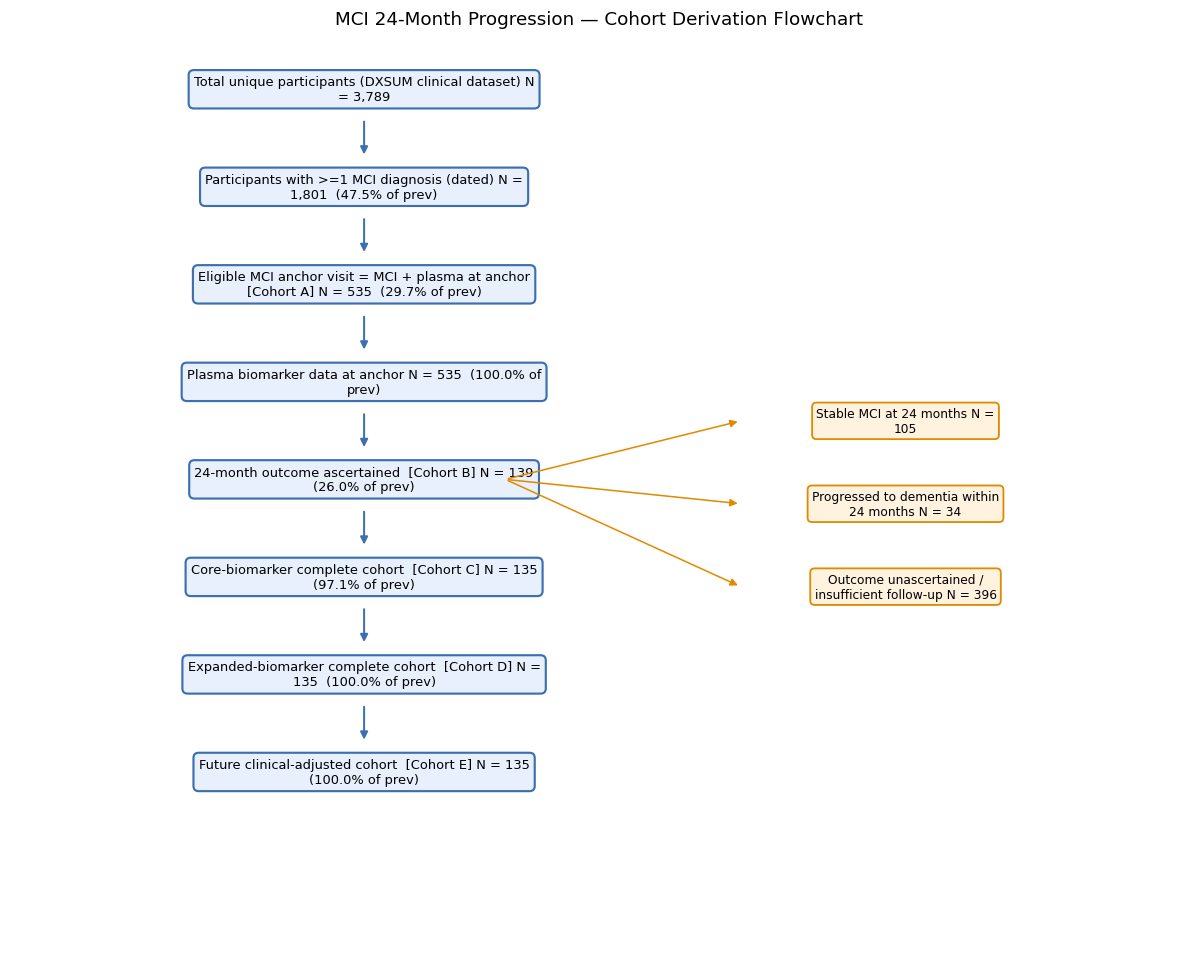

In [13]:
# ---- render flowchart figure ----
fig, ax = plt.subplots(figsize=(11, 9))
ax.axis("off")
main_steps = [r for _, r in flow_df.iterrows() if not r["step"].strip().startswith("-")]
sub_steps = [r for _, r in flow_df.iterrows() if r["step"].strip().startswith("-")]

y = 1.0
dy = 1.0 / (len(main_steps) + 1)
box_kw = dict(boxstyle="round,pad=0.4", facecolor="#e8f0fe", edgecolor="#3b6fb0", linewidth=1.4)
positions = {}
for r in main_steps:
    txt = f"{r['step']}\nN = {r['n']:,}" + (f"  ({r['pct_of_prev_step']}% of prev)"
                                            if pd.notna(r["pct_of_prev_step"]) else "")
    ax.text(0.30, y, textwrap.fill(txt, 52), ha="center", va="center", fontsize=8.5, bbox=box_kw)
    positions[r["step"]] = y
    y -= dy

# arrows between consecutive main boxes
ys = list(positions.values())
for i in range(len(ys) - 1):
    ax.annotate("", xy=(0.30, ys[i+1] + dy*0.30), xytext=(0.30, ys[i] - dy*0.30),
                arrowprops=dict(arrowstyle="-|>", color="#3b6fb0", lw=1.3))

# outcome sub-boxes to the right of the "24-month outcome ascertained" box
asc_y = positions["24-month outcome ascertained  [Cohort B]"]
sub_kw = dict(boxstyle="round,pad=0.35", facecolor="#fff3e0", edgecolor="#e08a00", linewidth=1.2)
sy = asc_y + dy*0.6
for r in sub_steps:
    label = r["step"].strip().lstrip("- ")
    ax.text(0.76, sy, textwrap.fill(f"{label}\nN = {r['n']:,}", 30),
            ha="center", va="center", fontsize=8, bbox=sub_kw)
    ax.annotate("", xy=(0.62, sy), xytext=(0.42, asc_y),
                arrowprops=dict(arrowstyle="-|>", color="#e08a00", lw=1.0))
    sy -= dy*0.85

ax.set_title("MCI 24-Month Progression — Cohort Derivation Flowchart", fontsize=12, pad=14)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(OUT_DIR / "cohort_flowchart.png", dpi=150, bbox_inches="tight")
print("saved -> cohort_flowchart.png")
plt.show()


## 10. Cohort sample-size table

In [14]:
sizes = pd.DataFrame([
    ("All MCI participants (dated, plasma not required)", n_mci_any,
     "Broader denominator / context"),
    ("Clinical MCI cohort (A) = MCI + plasma anchor", n_anchor,
     "Study anchor cohort"),
    ("Outcome-ascertained MCI cohort (B)", n_ascertained, "Stable + Progressed"),
    ("  Stable MCI at 24m", n_stable, ""),
    ("  Progressed to dementia within 24m", n_progressed, ""),
    ("  Unascertained outcome", n_unasc, "Insufficient / out-of-window follow-up"),
    ("Core-biomarker complete cohort (C)", n_core, "Outcome-ascertained + full core panel"),
    ("Expanded-biomarker complete cohort (D)", n_expanded, "C + Aβ40 + Aβ42/Aβ40 ratio"),
    ("Clinical-adjusted cohort (E)", n_clinadj,
     "= C; sex/education/comorbidities NOT in data"),
], columns=["cohort_definition", "n_participants", "notes"])
save_table(sizes, "cohort_sample_sizes.csv")
sizes


  saved -> outputs/01_mci_24m_cohort_audit/cohort_sample_sizes.csv  (9 rows x 3 cols)


,cohort_definition,n_participants,notes
0,"All MCI participants (dated, plasma not required)",1801,Broader denominator / context
1,Clinical MCI cohort (A) = MCI + plasma anchor,535,Study anchor cohort
2,Outcome-ascertained MCI cohort (B),139,Stable + Progressed
3,Stable MCI at 24m,105,
4,Progressed to dementia within 24m,34,
5,Unascertained outcome,396,Insufficient / out-of-window follow-up
6,Core-biomarker complete cohort (C),135,Outcome-ascertained + full core panel
7,Expanded-biomarker complete cohort (D),135,C + Aβ40 + Aβ42/Aβ40 ratio
8,Clinical-adjusted cohort (E),135,= C; sex/education/comorbidities NOT in data


## 11. 24-month conversion outcome summary

In [15]:
asc = master[master["flag_outcome_ascertained"]].copy()
n_asc = len(asc)
conv = pd.DataFrame([
    ("Stable MCI at 24 months", n_stable, round(100*n_stable/n_asc, 1) if n_asc else np.nan),
    ("Progressed to dementia within 24 months", n_progressed,
     round(100*n_progressed/n_asc, 1) if n_asc else np.nan),
    ("Outcome unascertained", n_unasc, np.nan),
    ("Converted only after 24 months (sensitivity)",
     int(master["ever_converted_after_24m"].sum()), np.nan),
], columns=["outcome_group", "n", "pct_of_ascertained"])
save_table(conv, "conversion_outcome_summary.csv")

# follow-up duration stats (ascertained cohort)
fu = master.loc[master["flag_outcome_ascertained"], "followup_months"].dropna()
early_conv = int((master["time_to_dementia_months"] <= 12).sum())
extra = pd.DataFrame([
    ("median follow-up (months)", round(fu.median(), 1)),
    ("IQR follow-up (months)", f"{fu.quantile(.25):.1f} – {fu.quantile(.75):.1f}"),
    ("min / max follow-up (months)", f"{fu.min():.1f} / {fu.max():.1f}"),
    ("participants with an exact ~24m (m24) visit", int(master["exact_m24_visit"].sum())),
    ("classified via 18–30m ascertainment window (Stable)", n_stable),
    ("earlier conversion events (dementia <=12m)", early_conv),
    ("all conversion events within 24m", n_progressed),
], columns=["metric", "value"])
print(conv.to_string(index=False)); print()
print(extra.to_string(index=False))
extra.to_csv(OUT_DIR / "conversion_outcome_followup_stats.csv", index=False)
conv


  saved -> outputs/01_mci_24m_cohort_audit/conversion_outcome_summary.csv  (4 rows x 3 cols)
                               outcome_group   n  pct_of_ascertained
                     Stable MCI at 24 months 105                75.5
     Progressed to dementia within 24 months  34                24.5
                       Outcome unascertained 396                 NaN
Converted only after 24 months (sensitivity)  52                 NaN

                                             metric        value
                          median follow-up (months)         42.8
                             IQR follow-up (months)  24.7 – 70.7
                       min / max follow-up (months) 11.4 / 121.8
        participants with an exact ~24m (m24) visit          124
classified via 18–30m ascertainment window (Stable)          105
         earlier conversion events (dementia <=12m)           15
                   all conversion events within 24m           34


,outcome_group,n,pct_of_ascertained
0,Stable MCI at 24 months,105,75.5
1,Progressed to dementia within 24 months,34,24.5
2,Outcome unascertained,396,NaN
3,Converted only after 24 months (sensitivity),52,NaN


## 12. Missingness audit (no imputation performed)

In [16]:
# Variables to audit, with source metadata.
AUDIT_VARS = [
    ("ptau217", "UPENN_PLASMA...", "pT217_F", "float", "pg/mL (Fujirebio)"),
    ("abeta42", "UPENN_PLASMA...", "AB42_F", "float", "pg/mL (Fujirebio)"),
    ("abeta40", "UPENN_PLASMA...", "AB40_F", "float", "pg/mL (Fujirebio)"),
    ("ratio_ab42_ab40", "derived", "AB42_F/AB40_F", "float", "ratio"),
    ("nfl", "UPENN_PLASMA...", "NfL_Q", "float", "pg/mL (Quanterix)"),
    ("gfap", "UPENN_PLASMA...", "GFAP_Q", "float", "pg/mL (Quanterix)"),
    ("APOE4_COUNT", "APOERES", "GENOTYPE", "int", "ε4 alleles 0-2"),
    ("age", "My_Table", "entry_age", "float", "years (baseline)"),
    ("baseline_dx_harmonized", "DXSUM", "DIAGNOSIS", "cat", "CN/MCI/Dementia"),
    ("outcome", "DXSUM (follow-up)", "DIAGNOSIS", "cat", "Stable/Progressed/Unasc"),
    ("followup_months", "DXSUM (follow-up)", "EXAMDATE", "float", "months"),
    ("CDRSB", "CDR", "CDRSB", "float", "0-18"),
    ("FAQTOTAL", "FAQ", "FAQTOTAL", "float", "0-30"),
    ("MMSCORE", "MMSE", "MMSCORE", "float", "0-30"),
    ("MOCA", "MOCA", "MOCA", "float", "0-30"),
]
# Comorbidity fields requested but ABSENT from the data — audited as fully missing.
ABSENT_VARS = ["sex", "education", "race_ethnicity", "diabetes", "hypertension",
               "cardiovascular_disease", "stroke_TIA", "depression", "kidney_renal"]


def summarize_missingness(df: pd.DataFrame, cohort_label: str) -> pd.DataFrame:
    rows = []
    n = len(df)
    for var, src, rawcol, dtype, unit in AUDIT_VARS:
        avail = df[var].notna().sum() if var in df else 0
        rows.append(dict(variable=var, source=src, raw_column=rawcol, dtype=dtype, unit=unit,
                         n_available=int(avail), n_missing=int(n-avail),
                         pct_missing=round(100*(n-avail)/n, 1) if n else np.nan,
                         cohort=cohort_label))
    for var in ABSENT_VARS:
        rows.append(dict(variable=var, source="(not in data)", raw_column="(none)", dtype="-",
                         unit="-", n_available=0, n_missing=n, pct_missing=100.0, cohort=cohort_label))
    return pd.DataFrame(rows)


miss_clinical = summarize_missingness(master, "Clinical MCI (A)")
miss_ascert = summarize_missingness(asc, "Outcome-ascertained (B)")
missingness = pd.concat([miss_clinical, miss_ascert], ignore_index=True)
save_table(missingness, "missingness_core_variables.csv")
# Show the ascertained-cohort view (most study-relevant)
miss_ascert.sort_values("pct_missing", ascending=False)


  saved -> outputs/01_mci_24m_cohort_audit/missingness_core_variables.csv  (48 rows x 9 cols)


,variable,source,raw_column,dtype,unit,n_available,n_missing,pct_missing,cohort
23,kidney_renal,(not in data),(none),-,-,0,139,100.0,Outcome-ascertained (B)
22,depression,(not in data),(none),-,-,0,139,100.0,Outcome-ascertained (B)
21,stroke_TIA,(not in data),(none),-,-,0,139,100.0,Outcome-ascertained (B)
20,cardiovascular_disease,(not in data),(none),-,-,0,139,100.0,Outcome-ascertained (B)
19,hypertension,(not in data),(none),-,-,0,139,100.0,Outcome-ascertained (B)
18,diabetes,(not in data),(none),-,-,0,139,100.0,Outcome-ascertained (B)
17,race_ethnicity,(not in data),(none),-,-,0,139,100.0,Outcome-ascertained (B)
16,education,(not in data),(none),-,-,0,139,100.0,Outcome-ascertained (B)
15,sex,(not in data),(none),-,-,0,139,100.0,Outcome-ascertained (B)
14,MOCA,MOCA,MOCA,float,0-30,85,54,38.8,Outcome-ascertained (B)


In [17]:
# Missingness by outcome group (Stable vs Progressed)
panel_vars = ["ptau217", "abeta42", "abeta40", "ratio_ab42_ab40", "nfl", "gfap",
              "APOE4_COUNT", "age", "CDRSB", "FAQTOTAL", "MMSCORE", "MOCA"]
by_out = []
for grp in ["Stable", "Progressed"]:
    sub = master[master["outcome"] == grp]
    for v in panel_vars:
        by_out.append(dict(variable=v, outcome=grp, n=len(sub),
                           pct_missing=round(100*sub[v].isna().mean(), 1)))
miss_by_outcome = (pd.DataFrame(by_out)
                   .pivot(index="variable", columns="outcome", values="pct_missing")
                   .reset_index())
save_table(miss_by_outcome, "missingness_by_outcome.csv")
miss_by_outcome


  saved -> outputs/01_mci_24m_cohort_audit/missingness_by_outcome.csv  (12 rows x 3 cols)


outcome,variable,Progressed,Stable
0,APOE4_COUNT,2.9,1.0
1,CDRSB,41.2,31.4
2,FAQTOTAL,2.9,4.8
3,MMSCORE,5.9,5.7
4,MOCA,50.0,35.2
5,abeta40,5.9,0.0
6,abeta42,5.9,0.0
7,age,0.0,0.0
8,gfap,0.0,0.0
9,nfl,0.0,0.0


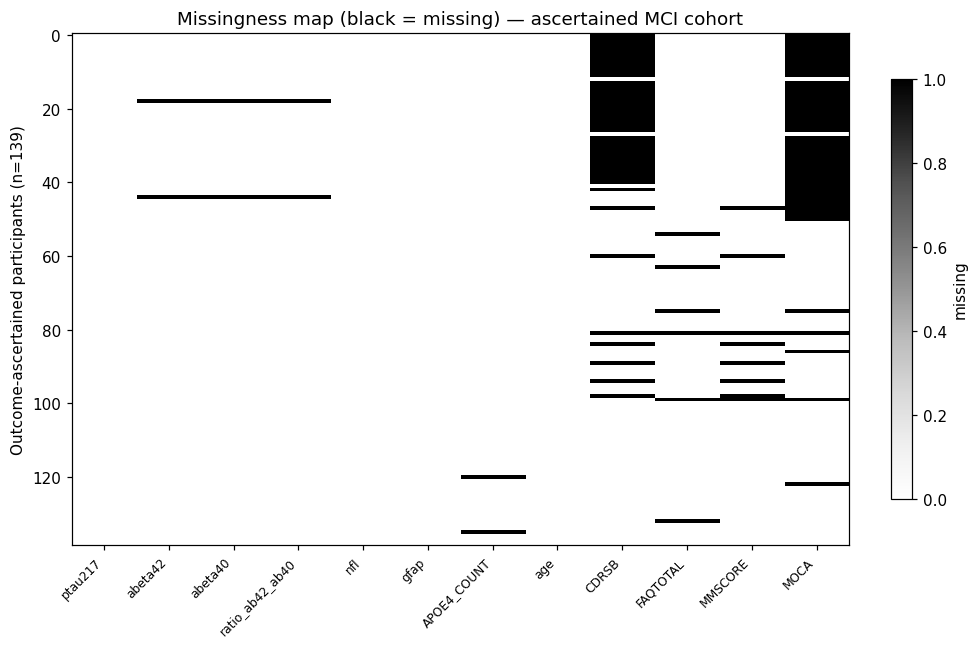

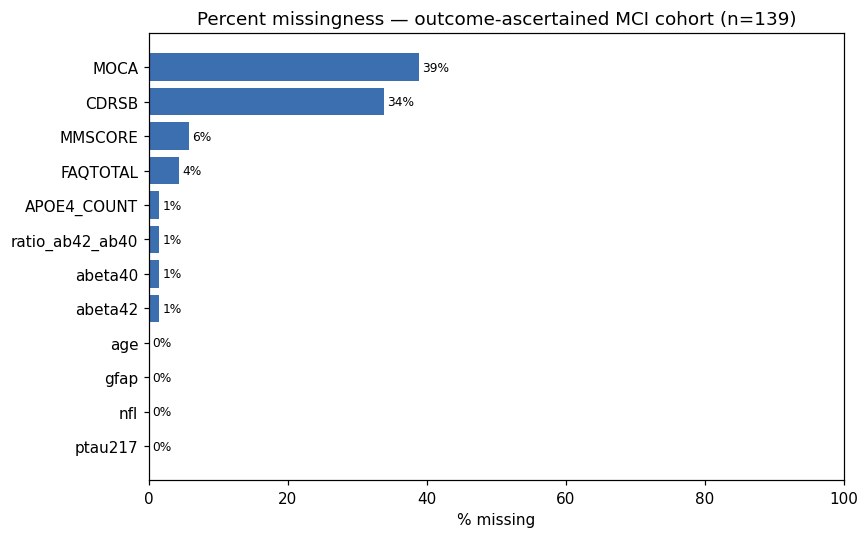

In [18]:
# Missingness heatmap (participant x variable) for the ascertained cohort core panel.
hm_vars = ["ptau217", "abeta42", "abeta40", "ratio_ab42_ab40", "nfl", "gfap",
           "APOE4_COUNT", "age", "CDRSB", "FAQTOTAL", "MMSCORE", "MOCA"]
M = asc[hm_vars].isna().astype(int).values
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(M, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
ax.set_xticks(range(len(hm_vars))); ax.set_xticklabels(hm_vars, rotation=45, ha="right", fontsize=8)
ax.set_ylabel(f"Outcome-ascertained participants (n={len(asc)})")
ax.set_title("Missingness map (black = missing) — ascertained MCI cohort")
plt.colorbar(im, ax=ax, fraction=0.025, label="missing")
plt.tight_layout()
fig.savefig(OUT_DIR / "missingness_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Percent-missing bar chart
pm = asc[hm_vars].isna().mean().mul(100).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(pm.index, pm.values, color="#3b6fb0")
for i, v in enumerate(pm.values):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=8)
ax.set_xlabel("% missing"); ax.set_xlim(0, 100)
ax.set_title(f"Percent missingness — outcome-ascertained MCI cohort (n={len(asc)})")
plt.tight_layout()
fig.savefig(OUT_DIR / "missingness_barplot.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Baseline characteristics: Stable MCI vs Progressed-to-dementia

Descriptive only — the purpose is feasibility, not causal inference. Standardized mean
differences (SMD) are reported as an effect-size guide, **not** hypothesis tests.

In [19]:
def smd(a: pd.Series, b: pd.Series) -> float:
    a, b = a.dropna(), b.dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    sp = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return np.nan if sp == 0 else (a.mean() - b.mean()) / sp


cont_vars = ["age", "APOE4_COUNT", "ptau217", "abeta42", "abeta40", "ratio_ab42_ab40",
             "nfl", "gfap", "CDRSB", "FAQTOTAL", "MMSCORE", "MOCA"]
S = master[master["outcome"] == "Stable"]
P = master[master["outcome"] == "Progressed"]

rows = []
for v in cont_vars:
    s, p = S[v], P[v]
    rows.append(dict(
        variable=v,
        stable_n=int(s.notna().sum()),
        stable_mean_sd=f"{s.mean():.3g} ± {s.std():.3g}" if s.notna().sum() else "-",
        stable_median_iqr=f"{s.median():.3g} [{s.quantile(.25):.3g}, {s.quantile(.75):.3g}]" if s.notna().sum() else "-",
        prog_n=int(p.notna().sum()),
        prog_mean_sd=f"{p.mean():.3g} ± {p.std():.3g}" if p.notna().sum() else "-",
        prog_median_iqr=f"{p.median():.3g} [{p.quantile(.25):.3g}, {p.quantile(.75):.3g}]" if p.notna().sum() else "-",
        SMD=round(smd(s, p), 3),
    ))
# sex counts (categorical) — NOT AVAILABLE, documented placeholder row
baseline_tbl = pd.DataFrame(rows)
save_table(baseline_tbl, "table_baseline_characteristics.csv")
baseline_tbl


  saved -> outputs/01_mci_24m_cohort_audit/table_baseline_characteristics.csv  (12 rows x 8 cols)


,variable,stable_n,stable_mean_sd,stable_median_iqr,prog_n,prog_mean_sd,prog_median_iqr,SMD
0,age,105,73.7 ± 7.14,"73.8 [69.6, 77.2]",34,74.8 ± 6.1,"74 [71.5, 78.2]",-0.173
1,APOE4_COUNT,104,0.577 ± 0.692,"0 [0, 1]",33,0.727 ± 0.674,"1 [0, 1]",-0.220
2,ptau217,105,0.27 ± 0.246,"0.184 [0.11, 0.356]",34,0.581 ± 0.358,"0.591 [0.321, 0.695]",-1.013
3,abeta42,105,25.2 ± 7.53,"25.1 [21.1, 29.2]",32,23.9 ± 6.41,"23.9 [21, 27.1]",0.192
4,abeta40,105,299 ± 76,"309 [263, 328]",32,300 ± 82.6,"294 [261, 340]",-0.014
5,ratio_ab42_ab40,105,0.0845 ± 0.0115,"0.084 [0.0753, 0.0929]",32,0.0802 ± 0.00698,"0.0803 [0.077, 0.0836]",0.456
6,nfl,105,25.6 ± 23.5,"20.7 [15.5, 29.4]",34,31.7 ± 17.6,"29.2 [20.5, 33.3]",-0.293
7,gfap,105,185 ± 97.5,"170 [114, 238]",34,267 ± 140,"240 [195, 300]",-0.687
8,CDRSB,72,1.5 ± 1.21,"1 [0.875, 2]",20,2.83 ± 2.17,"2 [1.5, 3.12]",-0.753
9,FAQTOTAL,100,3.16 ± 4.04,"1 [0, 5]",33,7.21 ± 5.5,"6 [3, 10]",-0.839


/var/folders/w0/vpjflhqx1z3dt_bmk6rwvkdw0000gn/T/ipykernel_53057/1795696144.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Stable", "Progressed"], showfliers=False)
/var/folders/w0/vpjflhqx1z3dt_bmk6rwvkdw0000gn/T/ipykernel_53057/1795696144.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Stable", "Progressed"], showfliers=False)
/var/folders/w0/vpjflhqx1z3dt_bmk6rwvkdw0000gn/T/ipykernel_53057/1795696144.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Stable", "Progressed"], showfliers=False)
/var/folders/w0/vpjflhqx1z3dt_bmk6rwv

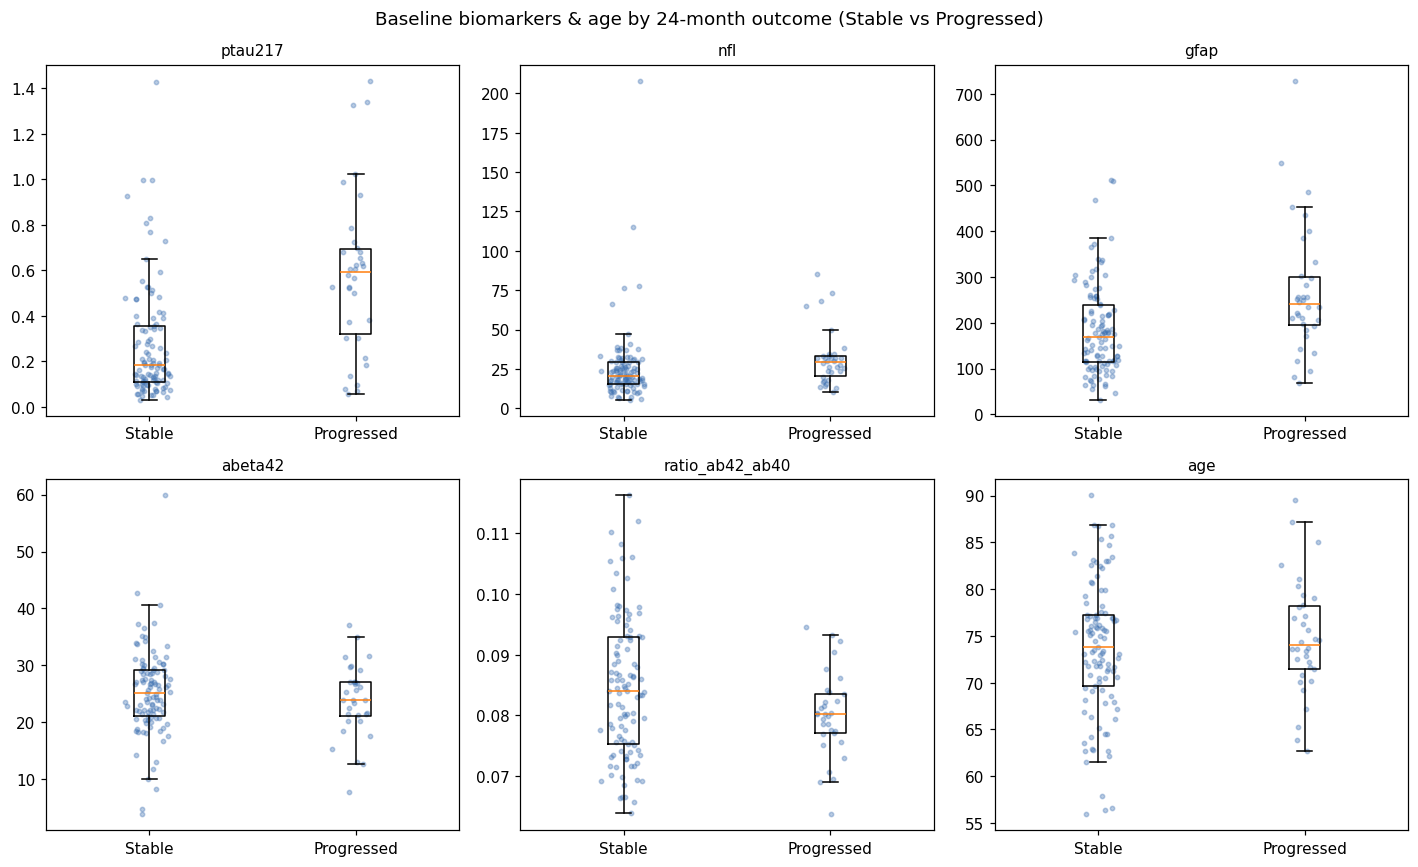

/var/folders/w0/vpjflhqx1z3dt_bmk6rwvkdw0000gn/T/ipykernel_53057/1795696144.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Stable", "Progressed"], showfliers=False)


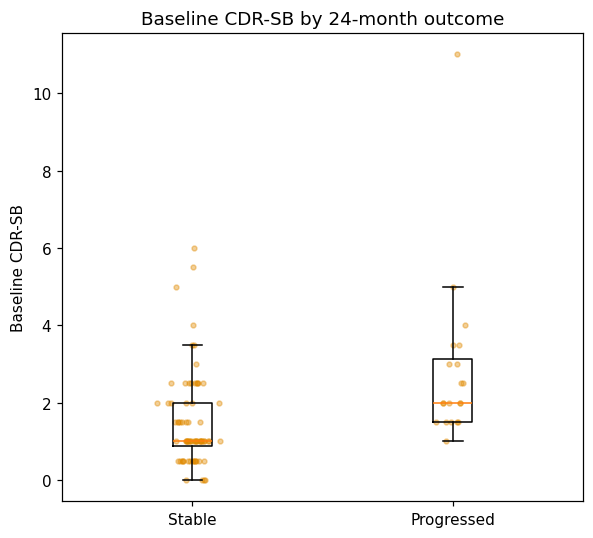

In [20]:
# Biomarker distributions stratified by outcome (boxplots), plus age and CDR-SB.
plot_biom = ["ptau217", "nfl", "gfap", "abeta42", "ratio_ab42_ab40", "age"]
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, v in zip(axes.ravel(), plot_biom):
    data = [S[v].dropna(), P[v].dropna()]
    if all(len(d) for d in data):
        ax.boxplot(data, labels=["Stable", "Progressed"], showfliers=False)
        # jittered points
        for i, d in enumerate(data, start=1):
            xs = np.random.default_rng(0).normal(i, 0.05, len(d))
            ax.scatter(xs, d, s=8, alpha=0.35, color="#3b6fb0")
    ax.set_title(v, fontsize=10)
fig.suptitle("Baseline biomarkers & age by 24-month outcome (Stable vs Progressed)", fontsize=12)
plt.tight_layout()
fig.savefig(OUT_DIR / "biomarker_distributions_by_outcome.png", dpi=150, bbox_inches="tight")
plt.show()

# dedicated baseline CDR-SB by outcome
fig, ax = plt.subplots(figsize=(5.5, 5))
data = [S["CDRSB"].dropna(), P["CDRSB"].dropna()]
if all(len(d) for d in data):
    ax.boxplot(data, labels=["Stable", "Progressed"], showfliers=False)
    for i, d in enumerate(data, start=1):
        xs = np.random.default_rng(1).normal(i, 0.05, len(d))
        ax.scatter(xs, d, s=10, alpha=0.4, color="#e08a00")
ax.set_ylabel("Baseline CDR-SB"); ax.set_title("Baseline CDR-SB by 24-month outcome")
plt.tight_layout()
fig.savefig(OUT_DIR / "baseline_cdrsb_by_outcome.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Data dictionary (future-study variables)

In [21]:
dd = [
    dict(analysis_variable="ptau217", raw_source_file="UPENN_PLASMA_FUJIREBIO_QUANTERIX",
         raw_source_column="pT217_F", id_field="RID", visit_field="VISCODE2/EXAMDATE",
         timepoint_rule="anchor plasma draw", definition="Fujirebio plasma p-tau217",
         unit="pg/mL", role="primary biomarker predictor",
         notes="log-transform likely for future modeling; all values >0 after sentinel removal"),
    dict(analysis_variable="abeta42", raw_source_file="UPENN_PLASMA_FUJIREBIO_QUANTERIX",
         raw_source_column="AB42_F", id_field="RID", visit_field="VISCODE2/EXAMDATE",
         timepoint_rule="anchor plasma draw", definition="Fujirebio plasma Aβ42",
         unit="pg/mL", role="primary biomarker predictor", notes="few -4 sentinels -> NaN"),
    dict(analysis_variable="abeta40", raw_source_file="UPENN_PLASMA_FUJIREBIO_QUANTERIX",
         raw_source_column="AB40_F", id_field="RID", visit_field="VISCODE2/EXAMDATE",
         timepoint_rule="anchor plasma draw", definition="Fujirebio plasma Aβ40",
         unit="pg/mL", role="primary biomarker predictor", notes="enables Aβ42/Aβ40 ratio"),
    dict(analysis_variable="ratio_ab42_ab40", raw_source_file="derived",
         raw_source_column="AB42_F / AB40_F", id_field="RID", visit_field="VISCODE2/EXAMDATE",
         timepoint_rule="anchor plasma draw", definition="recomputed Aβ42/Aβ40 ratio (derived)",
         unit="ratio", role="primary biomarker predictor",
         notes="vendor AB42_AB40_F retained separately; agreement checked"),
    dict(analysis_variable="nfl", raw_source_file="UPENN_PLASMA_FUJIREBIO_QUANTERIX",
         raw_source_column="NfL_Q", id_field="RID", visit_field="VISCODE2/EXAMDATE",
         timepoint_rule="anchor plasma draw", definition="Quanterix plasma NfL",
         unit="pg/mL", role="primary biomarker predictor",
         notes="use _Q (Quanterix); NfL_F mostly missing; log-transform likely"),
    dict(analysis_variable="gfap", raw_source_file="UPENN_PLASMA_FUJIREBIO_QUANTERIX",
         raw_source_column="GFAP_Q", id_field="RID", visit_field="VISCODE2/EXAMDATE",
         timepoint_rule="anchor plasma draw", definition="Quanterix plasma GFAP",
         unit="pg/mL", role="primary biomarker predictor", notes="use _Q; log-transform likely"),
    dict(analysis_variable="APOE4_COUNT", raw_source_file="APOERES",
         raw_source_column="GENOTYPE", id_field="RID", visit_field="bl/sc",
         timepoint_rule="time-invariant", definition="count of '4' in ε genotype",
         unit="alleles 0-2", role="genetic covariate", notes="never below detection"),
    dict(analysis_variable="age", raw_source_file="My_Table",
         raw_source_column="entry_age", id_field="PTID->RID", visit_field="(none)",
         timepoint_rule="study entry", definition="age at study entry",
         unit="years", role="demographic covariate",
         notes="baseline entry age, NOT age at anchor visit (limitation)"),
    dict(analysis_variable="baseline_dx_harmonized", raw_source_file="DXSUM",
         raw_source_column="DIAGNOSIS", id_field="RID", visit_field="VISCODE2/EXAMDATE",
         timepoint_rule="anchor +/-90d", definition="1=CN,2=MCI,3=Dementia -> label; anchor=MCI",
         unit="category", role="exclusion/quality-control variable",
         notes="anchor requires MCI"),
    dict(analysis_variable="outcome", raw_source_file="DXSUM (follow-up)",
         raw_source_column="DIAGNOSIS", id_field="RID", visit_field="EXAMDATE",
         timepoint_rule="post-anchor, <=24m event / 18-30m window",
         definition="Progressed (dementia<=24m) / Stable / Unascertained",
         unit="category", role="outcome-defining variable",
         notes="strictly post-anchor; leakage-guarded"),
    dict(analysis_variable="followup_months", raw_source_file="DXSUM (follow-up)",
         raw_source_column="EXAMDATE", id_field="RID", visit_field="EXAMDATE",
         timepoint_rule="max post-anchor dx date", definition="follow-up duration",
         unit="months", role="outcome-defining variable", notes=""),
    dict(analysis_variable="CDRSB", raw_source_file="CDR", raw_source_column="CDRSB",
         id_field="RID", visit_field="VISDATE", timepoint_rule="anchor +/-90d",
         definition="CDR Sum of Boxes", unit="0-18", role="clinical benchmark predictor",
         notes="future benchmark only, not primary biomarker"),
    dict(analysis_variable="FAQTOTAL", raw_source_file="FAQ", raw_source_column="FAQTOTAL",
         id_field="RID", visit_field="VISDATE", timepoint_rule="anchor +/-90d",
         definition="Functional Activities Questionnaire total", unit="0-30",
         role="clinical benchmark predictor", notes=""),
    dict(analysis_variable="MMSCORE", raw_source_file="MMSE", raw_source_column="MMSCORE",
         id_field="RID", visit_field="VISDATE", timepoint_rule="anchor +/-90d",
         definition="Mini-Mental State Exam total", unit="0-30",
         role="clinical benchmark predictor", notes=""),
    dict(analysis_variable="MOCA", raw_source_file="MOCA", raw_source_column="MOCA",
         id_field="RID", visit_field="VISDATE", timepoint_rule="anchor +/-90d",
         definition="Montreal Cognitive Assessment total", unit="0-30",
         role="clinical benchmark predictor", notes="not collected in ADNI1"),
]
for v in ["sex", "education", "race_ethnicity", "diabetes", "hypertension",
          "cardiovascular_disease", "stroke_TIA", "depression", "kidney_renal"]:
    dd.append(dict(analysis_variable=v, raw_source_file="(not in data)", raw_source_column="(none)",
                   id_field="-", visit_field="-", timepoint_rule="-",
                   definition="requested but absent from all project files", unit="-",
                   role="not available / not usable", notes="cannot be used in future study as-is"))
data_dictionary = pd.DataFrame(dd)
# attach realized missingness (ascertained cohort) where applicable
mmap = dict(zip(miss_ascert["variable"], miss_ascert["pct_missing"]))
data_dictionary["pct_missing_ascertained"] = data_dictionary["analysis_variable"].map(mmap)
save_table(data_dictionary, "data_dictionary_mci_24m_study.csv")
data_dictionary


  saved -> outputs/01_mci_24m_cohort_audit/data_dictionary_mci_24m_study.csv  (24 rows x 11 cols)


,analysis_variable,raw_source_file,raw_source_column,id_field,visit_field,timepoint_rule,definition,unit,role,notes,pct_missing_ascertained
0,ptau217,UPENN_PLASMA_FUJIREBIO_QUANTERIX,pT217_F,RID,VISCODE2/EXAMDATE,anchor plasma draw,Fujirebio plasma p-tau217,pg/mL,primary biomarker predictor,log-transform likely for future modeling; all ...,0.0
1,abeta42,UPENN_PLASMA_FUJIREBIO_QUANTERIX,AB42_F,RID,VISCODE2/EXAMDATE,anchor plasma draw,Fujirebio plasma Aβ42,pg/mL,primary biomarker predictor,few -4 sentinels -> NaN,1.4
2,abeta40,UPENN_PLASMA_FUJIREBIO_QUANTERIX,AB40_F,RID,VISCODE2/EXAMDATE,anchor plasma draw,Fujirebio plasma Aβ40,pg/mL,primary biomarker predictor,enables Aβ42/Aβ40 ratio,1.4
3,ratio_ab42_ab40,derived,AB42_F / AB40_F,RID,VISCODE2/EXAMDATE,anchor plasma draw,recomputed Aβ42/Aβ40 ratio (derived),ratio,primary biomarker predictor,vendor AB42_AB40_F retained separately; agreem...,1.4
4,nfl,UPENN_PLASMA_FUJIREBIO_QUANTERIX,NfL_Q,RID,VISCODE2/EXAMDATE,anchor plasma draw,Quanterix plasma NfL,pg/mL,primary biomarker predictor,use _Q (Quanterix); NfL_F mostly missing; log-...,0.0
5,gfap,UPENN_PLASMA_FUJIREBIO_QUANTERIX,GFAP_Q,RID,VISCODE2/EXAMDATE,anchor plasma draw,Quanterix plasma GFAP,pg/mL,primary biomarker predictor,use _Q; log-transform likely,0.0
6,APOE4_COUNT,APOERES,GENOTYPE,RID,bl/sc,time-invariant,count of '4' in ε genotype,alleles 0-2,genetic covariate,never below detection,1.4
7,age,My_Table,entry_age,PTID->RID,(none),study entry,age at study entry,years,demographic covariate,"baseline entry age, NOT age at anchor visit (l...",0.0
8,baseline_dx_harmonized,DXSUM,DIAGNOSIS,RID,VISCODE2/EXAMDATE,anchor +/-90d,"1=CN,2=MCI,3=Dementia -> label; anchor=MCI",category,exclusion/quality-control variable,anchor requires MCI,0.0
9,outcome,DXSUM (follow-up),DIAGNOSIS,RID,EXAMDATE,"post-anchor, <=24m event / 18-30m window",Progressed (dementia<=24m) / Stable / Unascert...,category,outcome-defining variable,strictly post-anchor; leakage-guarded,0.0


## 15. Feasibility Conclusion for 24-Month MCI Progression Modeling

In [22]:
ratio_feasible = n_expanded > 0
comorbid_usable = False  # none exist in data
# heuristic: regularized pilot wants roughly >=10 events per predictor; core panel ~6-8 predictors
events = n_progressed
epv_core = events / 8 if events else 0

lines = []
lines.append(f"1. Baseline MCI participants (with plasma anchor, Cohort A): {n_anchor}")
lines.append(f"   (all dated MCI participants, plasma not required: {n_mci_any})")
lines.append(f"2. Ascertainable 24-month outcome (Cohort B): {n_ascertained} "
             f"({100*n_ascertained/n_anchor:.0f}% of A)")
lines.append(f"3. Progressed to dementia within 24 months: {n_progressed} "
             f"({100*n_progressed/n_ascertained:.1f}% of ascertained)")
lines.append(f"4. Core-panel complete cases (Cohort C): {n_core}  "
             f"(progressed within C is the binding event count)")
lines.append(f"5. Aβ42/Aβ40 ratio feasible? {'YES' if ratio_feasible else 'NO'} "
             f"(expanded complete cohort D = {n_expanded})")
lines.append(f"6. Comorbidity variables usable? NO — sex, education, and every requested "
             f"comorbidity field are absent from the data (100% missing).")
lines.append(f"7. Event count sufficient for a small regularized pilot? "
             f"~{events} events => ~{epv_core:.1f} events per predictor at 8 predictors "
             f"({'borderline/adequate' if epv_core >= 5 else 'LOW'}).")
lines.append(f"8. Strongest limitation: {'few progression events / ' if events < 60 else ''}"
             f"no clinical covariates (sex, education, comorbidities) and single-cohort ADNI data.")
print("\n".join(lines))

# choose a recommendation
core_progressed = int(((master["outcome"] == "Progressed") & master["flag_has_core_panel"]).sum())
if core_progressed >= 40:
    rec = "A. Proceed to a small regularized pilot model"
elif core_progressed >= 15:
    rec = "B. Proceed only with a reduced predictor set due to limited event count"
else:
    rec = "D. Do not proceed to modeling without obtaining more follow-up / data"
print(f"\nCore-panel-complete participants who progressed: {core_progressed}")
print(f"RECOMMENDATION -> {rec}")


1. Baseline MCI participants (with plasma anchor, Cohort A): 535
   (all dated MCI participants, plasma not required: 1801)
2. Ascertainable 24-month outcome (Cohort B): 139 (26% of A)
3. Progressed to dementia within 24 months: 34 (24.5% of ascertained)
4. Core-panel complete cases (Cohort C): 135  (progressed within C is the binding event count)
5. Aβ42/Aβ40 ratio feasible? YES (expanded complete cohort D = 135)
6. Comorbidity variables usable? NO — sex, education, and every requested comorbidity field are absent from the data (100% missing).
7. Event count sufficient for a small regularized pilot? ~34 events => ~4.2 events per predictor at 8 predictors (LOW).
8. Strongest limitation: few progression events / no clinical covariates (sex, education, comorbidities) and single-cohort ADNI data.

Core-panel-complete participants who progressed: 31
RECOMMENDATION -> B. Proceed only with a reduced predictor set due to limited event count


### Interpretation (fill-in reflects the computed numbers above)

- The cohort is drawn from a **single ADNI-derived plasma dataset**; findings would be
  internal-only and require external validation before any clinical claim.
- **No clinical covariates** (sex, education, comorbidities) exist in these files, so the
  planned *clinical-adjusted* Model A/E cannot be built as specified — it collapses to
  *age + APOE4* plus biomarkers.
- Nothing here is "diagnostic," "validated," or "clinically ready." This is a feasibility
  audit only.
- The binding constraint on a pilot model is the **number of progression events among
  core-panel-complete participants**, printed above.

## 16. Handoff to `02_mci_24m_risk_model.ipynb` (plan only — do not implement here)

**Primary comparison**
- **Model A:** age + APOE4 (+ sex / education / comorbidities *if obtainable* — currently absent).
- **Model B:** Model A + p-tau217 + Aβ42/Aβ40 (if feasible) + NfL + GFAP.

**Sensitivity / benchmark**
- **Model C:** Model B + baseline CDR-SB (or another baseline cognitive score).

**Outcome:** MCI → dementia progression within 24 months (this notebook's `outcome` field).

**Model type:** regularized logistic regression / Elastic Net logistic regression.

**Secondary analyses:** calibration, ROC-AUC, PR-AUC, Brier score, balanced accuracy,
bootstrap confidence intervals, and a sensitivity analysis using continuous CDR-SB change.

> **Leakage discipline (mandatory):** all feature selection, scaling, imputation, and
> hyper-parameter tuning must happen **inside training folds only** during cross-validation.
> The analysis-ready table `mci_24m_anchor_cohort_raw.csv` preserves raw values so the
> future notebook controls every transformation.

**Recommended next step given the demographic/comorbidity gap:** either obtain ADNI
`PTDEMOG` (sex, education) and medical-history tables to enable the clinical-adjusted model,
or, if event counts are low, pursue **Option C** (a longitudinal continuous-outcome analysis
such as CDR-SB slope) as a complementary design.

---
*All artifacts written to `outputs/01_mci_24m_cohort_audit/`.*

In [23]:
# Inventory of exported artifacts
import glob
print("Artifacts in", OUT_DIR.relative_to(PROJECT_ROOT), ":")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:48s} {p.stat().st_size/1024:7.1f} KB")


Artifacts in outputs/01_mci_24m_cohort_audit :
  baseline_cdrsb_by_outcome.png                       30.3 KB
  biomarker_distributions_by_outcome.png             152.3 KB
  cohort_flow_counts.csv                               0.9 KB
  cohort_flowchart.png                               134.7 KB
  cohort_sample_sizes.csv                              0.6 KB
  conversion_outcome_followup_stats.csv                0.3 KB
  conversion_outcome_summary.csv                       0.2 KB
  data_dictionary_mci_24m_study.csv                    4.0 KB
  data_discovery_summary.csv                           2.3 KB
  diagnosis_harmonization.csv                          0.4 KB
  mci_24m_anchor_cohort_raw.csv                      127.8 KB
  missingness_barplot.png                             48.2 KB
  missingness_by_outcome.csv                           0.2 KB
  missingness_core_variables.csv                       3.6 KB
  missingness_heatmap.png                             62.0 KB
  table_baseline_charac